# Sudoku CNN — Dataset Quality Analysis

Living notebook for evaluating the composition, label quality, and distribution
of the training data that feeds `app/ml/train.py`. It answers:

1. **What sources are in the training pool?** Sizes + per-split composition.
2. **Is the class distribution balanced?** Histograms per train/val/test.
3. **Is the label quality clean?** Two-stage font filter audit + visual check
   on both accepted and rejected fonts.
4. **Do the samples look right?** One-per-digit sanity grid across MNIST,
   `PrintedDigitDataset`, and `Chars74KFontDataset`.
5. **Is the test split honest?** Chars74K train/test font-disjoint assertion.
6. **Does the training distribution match real inference inputs?** Measured
   GT newspaper cell statistics (from `notebooks/gt_cell_measurement.py`) vs
   raw synthetic vs post-augmentation.
7. **Does the training-time augmentation actually do what it claims?** Visual
   before/after grid + per-metric distribution match against the GT target.

**Out of scope for this notebook:** inference-side evaluation (filled/empty
accuracy, confusion on real photos) — that lives in `notebooks/ocr_analysis.ipynb`
and `evaluation/evaluate_ocr.py`. This notebook is strictly about the data.

**Data-leakage rule:** the 38 GT newspaper photos are never pulled into any
training split. Their cells are used here only for *measuring* the target
distribution the augmentation should match. Every plot in section 6 is of a
read-only statistic file, not of model predictions on GT cells.

**Upstream pipeline:** `app/ml/dataset.py::create_datasets` concatenates MNIST
+ `EmptyCellDataset` + `PrintedDigitDataset` + `Chars74KFontDataset`. The
training-time augmentation (geometric + newsprint) is in `AugmentedDataset`.
The newsprint augmentation parameters were tuned against the GT distribution
by the inline sweep harness used during the 2026-04-10 redesign.


In [1]:
import os
import sys
from pathlib import Path

# Walk up from CWD to find the project root (the directory containing ``app/``),
# then add it to sys.path and chdir into it. This makes the notebook robust to
# being executed from any directory — ``jupyter nbconvert --execute --inplace``
# runs with CWD = invocation directory, which may or may not be the project
# root, so a plain ``sys.path.insert(0, '..')`` would be fragile.
PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "app").is_dir() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "app").is_dir():
    raise RuntimeError(
        f"Couldn't find project root (containing app/) from {Path.cwd()}"
    )
sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)
print(f"CWD: {Path.cwd()}")

import importlib
import json
from collections import Counter

import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import ConcatDataset

# Force-reload app.ml.dataset so we pick up any edits made while this
# Jupyter kernel was alive. Without this, `from app.ml.dataset import X`
# returns whatever module object was cached in sys.modules, which may
# have been imported before we added new symbols (LATIN_FONT_ALLOWLIST,
# Chars74KFontDataset, etc.) — you'd then get an ImportError for the
# new names even though the file on disk has them.
import app.ml.dataset as _ds
importlib.reload(_ds)

from app.ml.dataset import (
    LATIN_FONT_ALLOWLIST,
    AugmentedDataset,
    Chars74KFontDataset,
    EmptyCellDataset,
    PrintedDigitDataset,
    _font_has_distinct_latin_digits,
    _is_latin_allowlisted_font,
    _load_mnist,
    create_datasets,
)

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100


CWD: /Users/adityajoshi/Documents/ClaudeTest/VSCodium/Sudoku-Solved


## 1. Dataset composition


In [2]:
# Build the combined splits and the individual sources side-by-side.
train_ds, val_ds, test_ds = create_datasets()

mnist_train   = _load_mnist(train=True)
mnist_test    = _load_mnist(train=False)
empty_train   = EmptyCellDataset(count=5000, seed=42)
printed       = PrintedDigitDataset()
chars74k_tr   = Chars74KFontDataset(split='train')
chars74k_te   = Chars74KFontDataset(split='test')

print('--- Combined splits ---')
print(f'train  : {len(train_ds):>6,} samples')
print(f'val    : {len(val_ds):>6,} samples')
print(f'test   : {len(test_ds):>6,} samples')
print(f'total  : {len(train_ds) + len(val_ds) + len(test_ds):>6,} samples')

print()
print('--- Individual sources ---')
rows = [
    ('MNIST train',                 len(mnist_train),  '—'),
    ('MNIST test',                  len(mnist_test),   '—'),
    ('EmptyCellDataset (train)',    len(empty_train),  '—'),
    ('PrintedDigitDataset',         len(printed),      f'{len(printed.fonts)} fonts'),
    ('Chars74KFontDataset (train)', len(chars74k_tr),  f'{len(chars74k_tr.font_ids)} fonts'),
    ('Chars74KFontDataset (test)',  len(chars74k_te),  f'{len(chars74k_te.font_ids)} fonts'),
]
for name, n, extra in rows:
    print(f'{name:<32} {n:>6,} samples   {extra}')


--- Combined splits ---
train  : 69,128 samples
val    :  7,680 samples
test   : 12,836 samples
total  : 89,644 samples

--- Individual sources ---
MNIST train                      60,000 samples   —
MNIST test                       10,000 samples   —
EmptyCellDataset (train)          5,000 samples   —
PrintedDigitDataset               4,500 samples   67 fonts
Chars74KFontDataset (train)       7,308 samples   812 fonts
Chars74KFontDataset (test)        1,836 samples   204 fonts


## 2. Class balance

Balanced classes matter — a class-0-heavy training set biases the model toward
predicting "empty" on uncertain cells. Reported: per-split histograms + the
max/min imbalance ratio + class-0 share (uniform would be 10%).


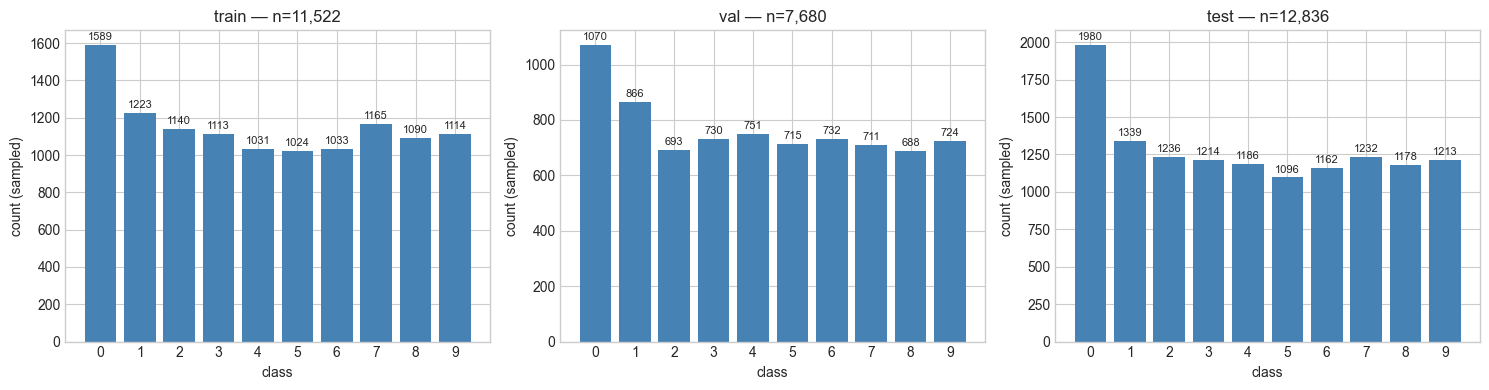


split      class 0 %     max/min ratio
----------------------------------------
train          13.8%             1.55x
val            13.9%             1.56x
test           15.4%             1.81x


In [3]:
def count_labels(ds, max_samples=10000):
    n = min(len(ds), max_samples)
    stride = max(1, len(ds) // n)
    counts = Counter()
    for i in range(0, len(ds), stride):
        _, lbl = ds[i]
        counts[int(lbl)] += 1
    return counts

train_counts = count_labels(train_ds)
val_counts   = count_labels(val_ds)
test_counts  = count_labels(test_ds)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, counts, name in zip(axes, (train_counts, val_counts, test_counts), ('train', 'val', 'test')):
    digits = list(range(10))
    vals = [counts.get(d, 0) for d in digits]
    bars = ax.bar(digits, vals, color='steelblue')
    ax.set_xlabel('class')
    ax.set_ylabel('count (sampled)')
    ax.set_title(f'{name} — n={sum(vals):,}')
    ax.set_xticks(digits)
    for d, v in zip(digits, vals):
        ax.text(d, v + max(vals) * 0.01, str(v), ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

print()
print(f'{"split":<8}{"class 0 %":>12}{"max/min ratio":>18}')
print('-' * 40)
for name, counts in (('train', train_counts), ('val', val_counts), ('test', test_counts)):
    total = sum(counts.values())
    max_c, min_c = max(counts.values()), min(counts.values())
    print(f'{name:<8}{100 * counts[0] / total:>11.1f}%{max_c / min_c:>17.2f}x')


## 3. Font filter audit

`PrintedDigitDataset` runs a two-stage filter over every discovered system
font. Understanding which fonts pass / are rejected is the single biggest
lever on training-label quality for the printed-digit class — before the
2026-04-10 redesign, the old filter (`arr.max() > 50`) silently accepted
`LastResort.otf`, `Symbol.ttf`, CJK/Myanmar/Gujarati script fonts, and STIX
math fonts, producing mislabeled tofu samples.

**Stage 1** is a hardcoded **name allow-list** of ~35 known Latin font
family prefixes. Font basenames are matched case-insensitively; anything
outside the list is rejected up front. This kills the vast majority of
bad fonts with a deterministic, reproducible rule.

**Stage 2** renders digits 0-9 **centred** inside a 40x32 tile (wide enough
to fit bold fonts like Impact and Arial Black without clipping), then
computes the pairwise pixel correlation matrix and rejects the font if:

- any digit renders blank (max pixel < 50) — the font has no glyph at
  that codepoint, OR
- any pair of digits has correlation > 0.995 — two glyphs are literal
  duplicates, OR
- the **mean upper-triangular correlation exceeds 0.85** — the whole
  glyph set is tofu-like or near-identical.

The mean-correlation threshold was tuned empirically: real Latin fonts
land between mean ≈ 0.36 (Georgia Italic) and 0.77 (Impact), while
`LastResort.otf` (pure tofu) sits at mean ≈ 1.00. Using the *mean*
rather than the max catches tofu fonts while letting bold Latin fonts
through, because thick strokes naturally push the *max* pairwise
correlation up to ≈ 0.97 without indicating a real rendering problem.


In [4]:
font_dirs = [
    '/System/Library/Fonts',
    '/System/Library/Fonts/Supplemental',
    '/Library/Fonts',
    '/usr/share/fonts',
    '/usr/share/fonts/truetype',
]

all_fonts = []
for d in font_dirs:
    if not Path(d).is_dir():
        continue
    for f in Path(d).iterdir():
        if f.suffix.lower() in ('.ttf', '.ttc', '.otf'):
            all_fonts.append(str(f))

stage1_pass   = [fp for fp in all_fonts if _is_latin_allowlisted_font(fp)]
stage1_reject = [fp for fp in all_fonts if not _is_latin_allowlisted_font(fp)]

stage2_pass   = [fp for fp in stage1_pass if _font_has_distinct_latin_digits(fp)]
stage2_reject = [fp for fp in stage1_pass if fp not in set(stage2_pass)]

print(f'Discovered system fonts: {len(all_fonts):>4}')
print(f'  Stage 1 name allow-list: {len(stage1_pass):>4} pass  /  {len(stage1_reject):>4} reject')
print(f'  Stage 2 signature test : {len(stage2_pass):>4} pass  /  {len(stage2_reject):>4} reject')
print(f'  Final fonts used       : {len(stage2_pass):>4}')
print(f'  Allow-list entries     : {len(LATIN_FONT_ALLOWLIST):>4}')

print()
print('--- Sample Stage 1 rejections (not in the Latin allow-list) ---')
notable_keywords = ('LastResort', 'Symbol', 'STIX', 'Myanmar', 'CJK', 'Gunjala',
                    'Apple Color Emoji', 'Hiragino', 'PingFang', 'Dingbat')
interesting_rejects = [fp for fp in stage1_reject
                       if any(kw in Path(fp).name for kw in notable_keywords)]
for fp in interesting_rejects[:12]:
    print(f'  {Path(fp).name}')
print(f'  ... ({len(stage1_reject) - 12:,} more)')

if stage2_reject:
    print()
    print('--- Stage 2 rejections (allowlisted but fail signature test) ---')
    for fp in stage2_reject:
        print(f'  {Path(fp).name}')
else:
    print()
    print('Stage 2: all allowlisted fonts pass the signature test.')


Discovered system fonts:  371
  Stage 1 name allow-list:   67 pass  /   304 reject
  Stage 2 signature test :   67 pass  /     0 reject
  Final fonts used       :   67
  Allow-list entries     :   35

--- Sample Stage 1 rejections (not in the Latin allow-list) ---
  Symbol.ttf
  Hiragino Sans GB.ttc
  LastResort.otf
  NotoSerifMyanmar.ttc
  ZapfDingbats.ttf
  NotoSansMyanmar.ttc
  Apple Symbols.ttf
  CJKSymbolsFallback.ttc
  Apple Color Emoji.ttc
  STIXGeneralItalic.otf
  STIXTwoText-Italic.ttf
  STIXIntUpSmReg.otf
  ... (292 more)

Stage 2: all allowlisted fonts pass the signature test.


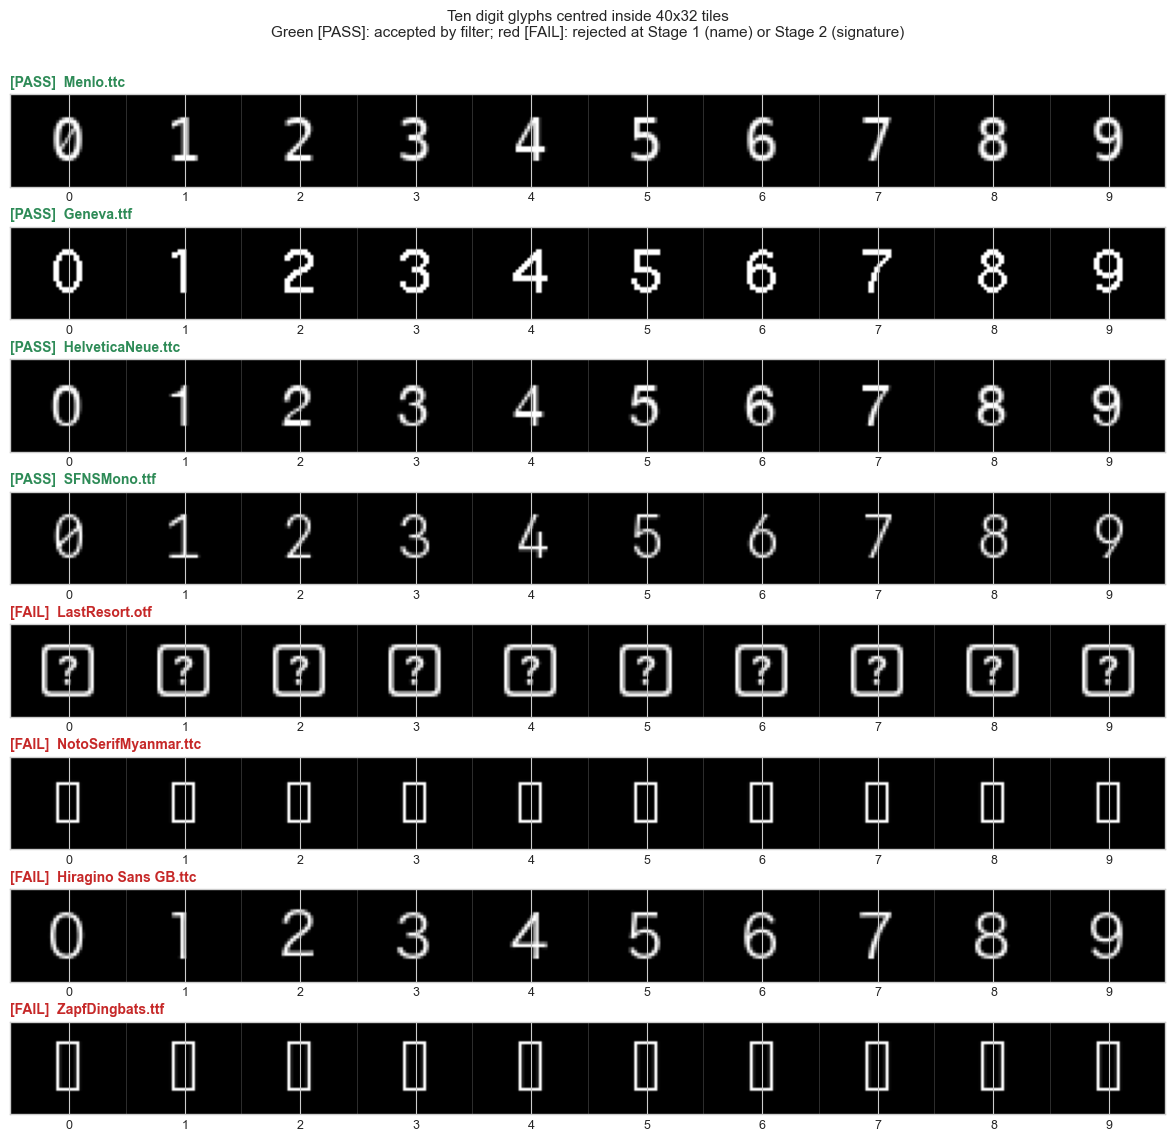

In [5]:
# Visual: 10-digit render of a few passing fonts vs a few notorious rejected fonts.
# Each glyph is centred inside a 40x32 tile using its actual bounding box,
# so wide/bold fonts (Geneva, Impact, Helvetica, etc.) don't spill into the
# neighbouring digit's tile.
from PIL import Image, ImageDraw, ImageFont

TILE_W, TILE_H = 40, 32

def render_all_digits(font_path, size=20):
    try:
        font = ImageFont.truetype(font_path, size)
    except Exception:
        return None
    grid = np.zeros((TILE_H, TILE_W * 10), dtype=np.uint8)
    for d in range(10):
        img = Image.new('L', (TILE_W, TILE_H), 0)
        draw = ImageDraw.Draw(img)
        bbox = draw.textbbox((0, 0), str(d), font=font)
        gw, gh = bbox[2] - bbox[0], bbox[3] - bbox[1]
        # Centre the glyph inside the tile, accounting for the bbox offset
        # (textbbox origin is where the pen starts, not where ink begins).
        x = (TILE_W - gw) // 2 - bbox[0]
        y = (TILE_H - gh) // 2 - bbox[1]
        draw.text((x, y), str(d), fill=255, font=font)
        grid[:, d*TILE_W:(d+1)*TILE_W] = np.array(img)
    return grid

show_pass = stage2_pass[:4]
# Hand-picked rejection examples that visibly fail — not ones that happen to
# render Latin digits at ASCII codepoints (like Symbol.ttf, which is rejected
# by the name allow-list but would look 'fine' here and confuse the reader).
reject_keywords = ('LastResort', 'NotoSerifMyanmar', 'Hiragino Sans GB',
                   'ZapfDingbats', 'CJKSymbolsFallback', 'Bodoni Ornaments')
show_reject = []
for kw in reject_keywords:
    for fp in all_fonts:
        if kw in Path(fp).name and fp not in show_reject:
            show_reject.append(fp)
            break
    if len(show_reject) >= 4:
        break
show_reject = show_reject[:4]

rows = [(fp, True) for fp in show_pass] + [(fp, False) for fp in show_reject]
fig, axes = plt.subplots(len(rows), 1, figsize=(13, 1.4 * len(rows)))
for ax, (fp, is_pass) in zip(axes, rows):
    grid = render_all_digits(fp)
    if grid is None:
        grid = np.zeros((TILE_H, TILE_W * 10), dtype=np.uint8)
    ax.imshow(grid, cmap='gray', aspect='equal', vmin=0, vmax=255)
    mark = '[PASS]' if is_pass else '[FAIL]'
    color = '#2E8B57' if is_pass else '#C62828'
    ax.set_title(f'{mark}  {Path(fp).name}', fontsize=10, color=color, loc='left',
                 fontweight='bold')
    ax.set_yticks([])
    ax.set_xticks([i * TILE_W + TILE_W // 2 for i in range(10)])
    ax.set_xticklabels([str(d) for d in range(10)], fontsize=9)
    # Draw faint separator lines between tiles so it's obvious where the
    # boundaries are and that each digit is confined to its own column.
    for i in range(1, 10):
        ax.axvline(i * TILE_W - 0.5, color='#404040', linewidth=0.5)

plt.suptitle('Ten digit glyphs centred inside 40x32 tiles\n'
             'Green [PASS]: accepted by filter; red [FAIL]: rejected at Stage 1 (name) or Stage 2 (signature)',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.show()


## 4. Per-source sample inspection

One sample per digit (0-9) from each real training source. Label mismatches
are visually obvious — if the image under the column header `5` doesn't look
like a "5", the source has a label bug.

`PrintedDigitDataset` and `Chars74KFontDataset` intentionally skip class 0
because class 0 in this project means "empty cell", not "digit zero" — see
the module docstring in `app/ml/dataset.py`.


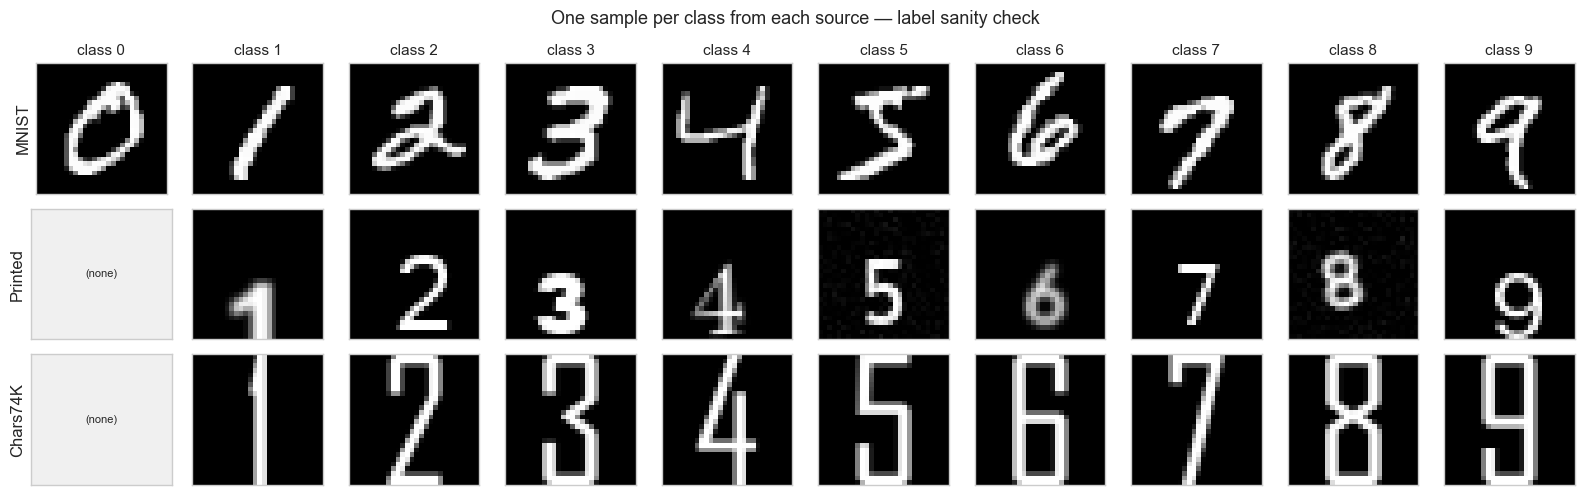

In [6]:
def first_n_per_digit(ds, n=1):
    result = {d: [] for d in range(10)}
    for i in range(len(ds)):
        _, lbl = ds[i]
        lbl = int(lbl)
        if lbl in result and len(result[lbl]) < n:
            result[lbl].append(i)
        if all(len(v) >= n for v in result.values() if v is not None):
            break
    return result

def to_img(sample):
    if isinstance(sample, torch.Tensor):
        return (sample.squeeze(0).numpy() * 255).astype(np.uint8)
    return np.asarray(sample, dtype=np.uint8)

sources = [
    ('MNIST',   mnist_train),
    ('Printed', printed),
    ('Chars74K', chars74k_tr),
]

fig, axes = plt.subplots(3, 10, figsize=(16, 5))
for row, (name, ds) in enumerate(sources):
    idxs = first_n_per_digit(ds, n=1)
    for d in range(10):
        ax = axes[row, d]
        ax.set_xticks([])
        ax.set_yticks([])
        if idxs[d]:
            img, _ = ds[idxs[d][0]]
            ax.imshow(to_img(img), cmap='gray', vmin=0, vmax=255)
        else:
            ax.set_facecolor('#f0f0f0')
            ax.text(0.5, 0.5, '(none)', ha='center', va='center', fontsize=8, transform=ax.transAxes)
        if row == 0:
            ax.set_title(f'class {d}', fontsize=11)
        if d == 0:
            ax.set_ylabel(name, fontsize=12)

plt.suptitle('One sample per class from each source — label sanity check', fontsize=13)
plt.tight_layout()
plt.show()


## 5. Chars74K train/test font-disjoint verification

The Chars74K English-Font archive has ~1016 unique font renderings per digit
class. `Chars74KFontDataset` partitions them by **font identity** (same
instance index across different Sample directories = same font), so the
test split measures generalisation to *unseen* fonts rather than memorisation.

This cell asserts the splits are disjoint and reports the ratio.


In [7]:
train_fonts = set(chars74k_tr.font_ids)
test_fonts  = set(chars74k_te.font_ids)

total_fonts = len(train_fonts | test_fonts)
overlap = len(train_fonts & test_fonts)

print(f'Chars74K train fonts : {len(train_fonts)}')
print(f'Chars74K test  fonts : {len(test_fonts)}')
print(f'Unique total         : {total_fonts}')
print(f'Overlap              : {overlap}')

assert overlap == 0, 'FONT LEAK: train and test share fonts'
print()
print(f'✓ Font-disjoint split verified.')
print(f'Split ratio: {100*len(train_fonts)/total_fonts:.1f}% train / {100*len(test_fonts)/total_fonts:.1f}% test')


Chars74K train fonts : 812
Chars74K test  fonts : 204
Unique total         : 1016
Overlap              : 0

✓ Font-disjoint split verified.
Split ratio: 79.9% train / 20.1% test


## 6. GT newspaper cells vs synthetic training sources

Compares the empirical distribution of **1720 filled / 1358 empty cells**
from the 38 GT newspaper photos against the raw synthetic training sources.
Data comes from `notebooks/gt_cell_stats.json`, produced by
`notebooks/gt_cell_measurement.py`. Re-run the measurement script if the GT
set changes.

**Two normalisation spaces, because both matter:**

- **`gt_filled` / `gt_empty`** — GT cells measured with margin crop +
  resize + invert **but no min-max normalize**. Directly comparable to the
  raw synthetic sources (`mnist`, `printed`, `chars74k`) which also live
  in this un-normalized space. Use this for section 6.
- **`gt_filled_postnorm` / `gt_empty_postnorm`** — GT cells measured
  through the **full `CNNRecognizer._preprocess` chain** (invert + min-max
  normalize). Directly comparable to the **post-augmentation** output of
  `AugmentedDataset`, because `_apply_newsprint` ends with the same
  min-max normalize step. Used in section 7.


In [8]:
stats_path = Path('gt_cell_stats.json')
if not stats_path.exists():
    stats_path = Path('notebooks/gt_cell_stats.json')

stats = json.loads(stats_path.read_text())
meta = stats['_meta']
sources_order = ('gt_filled', 'gt_empty', 'mnist', 'printed', 'chars74k')
metrics = ('mean', 'std', 'p5', 'p95', 'p95_p5', 'laplacian_var', 'mad_residual')

print(f'GT images loaded           : {meta["gt_images"]}')
print(f'GT filled cells            : {meta["gt_filled_cells"]:,}')
print(f'GT empty cells             : {meta["gt_empty_cells"]:,}')
print(f'Synthetic samples / source : {meta["synthetic_sample_n"]}')
print(f'Inner crop margin          : {meta["inner_crop_margin"]:.0%}')
print()

header = f'{"metric":<16}' + ''.join(f'{l:>12}' for l in sources_order)
print(header)
print('-' * len(header))
for k in metrics:
    row = f'{k:<16}'
    for src in sources_order:
        v = stats[src][k]['p50']
        row += f'{v:>12.1f}' if v is not None else f'{"—":>12}'
    print(row)


GT images loaded           : 38
GT filled cells            : 1,720
GT empty cells             : 1,358
Synthetic samples / source : 500
Inner crop margin          : 10%

metric             gt_filled    gt_empty       mnist     printed    chars74k
----------------------------------------------------------------------------
mean                    76.9        55.9        32.1        14.8        68.3
std                     30.9         7.7        76.4        49.7       104.9
p5                      50.0        44.0         0.0         0.0         0.0
p95                    151.8        81.8       252.0       143.8       255.0
p95_p5                  97.8        19.0       252.0       143.6       255.0
laplacian_var          742.1        97.0     10528.3      7276.9     13363.9
mad_residual             1.0         0.0         0.0         0.0         0.0


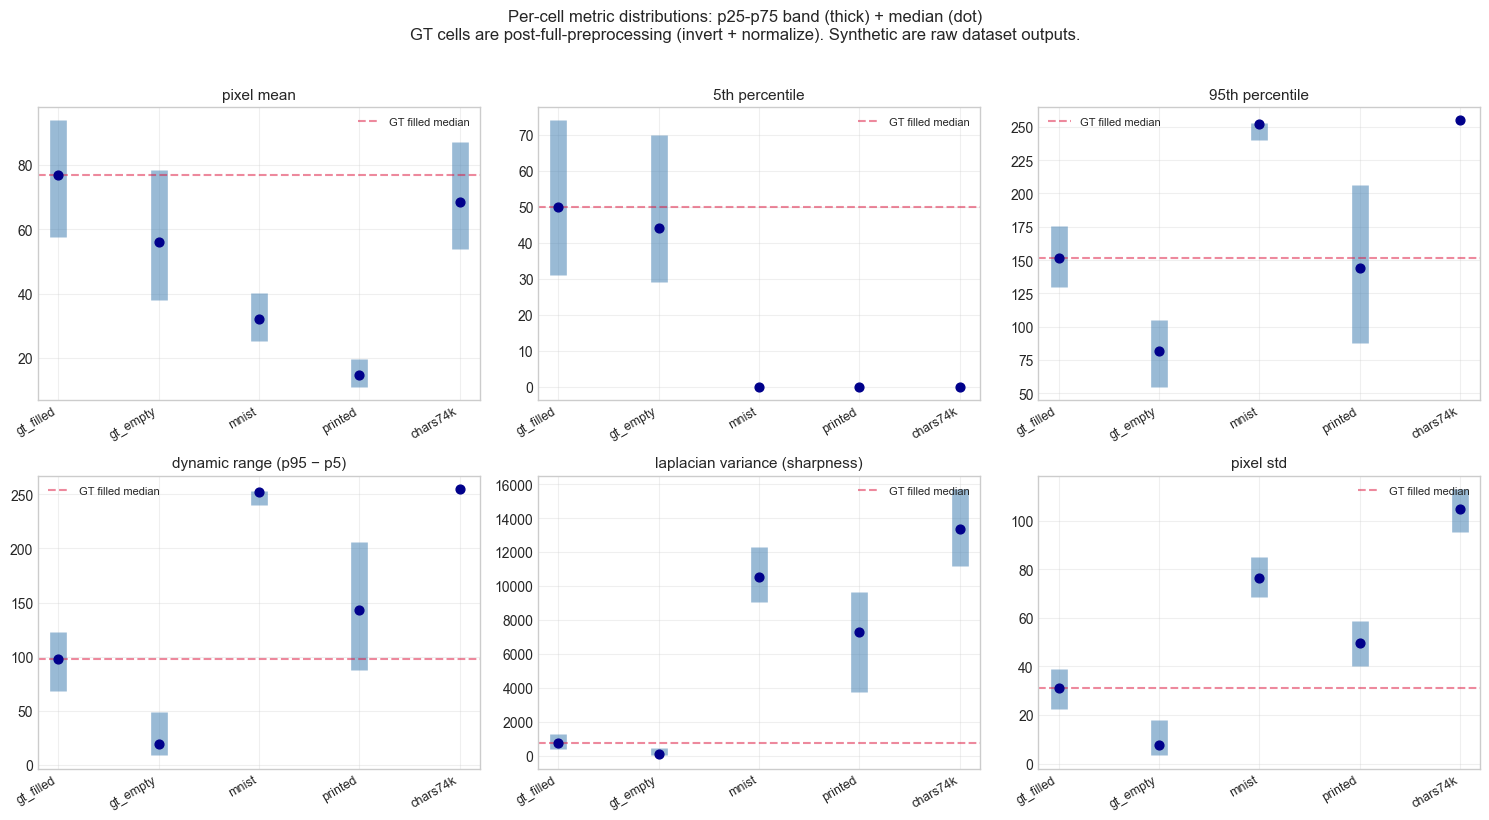

In [9]:
# IQR bars: for each metric, show p25-p75 (thick line) and median (dot)
plot_metrics = [
    ('mean',          'pixel mean'),
    ('p5',            '5th percentile'),
    ('p95',           '95th percentile'),
    ('p95_p5',        'dynamic range (p95 − p5)'),
    ('laplacian_var', 'laplacian variance (sharpness)'),
    ('std',           'pixel std'),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, (k, title) in zip(axes, plot_metrics):
    xs = []
    p25s, p50s, p75s = [], [], []
    labels = []
    for i, src in enumerate(sources_order):
        v = stats[src][k]
        if v['p50'] is None:
            continue
        xs.append(i)
        p25s.append(v['p25'])
        p50s.append(v['p50'])
        p75s.append(v['p75'])
        labels.append(src)

    ax.vlines(xs, p25s, p75s, color='steelblue', linewidth=12, alpha=0.55)
    ax.scatter(xs, p50s, color='darkblue', zorder=3, s=40)

    if len(xs) >= 2:
        # GT filled target line (at x = gt_filled's position)
        target = stats['gt_filled'][k]['p50']
        if target is not None:
            ax.axhline(target, color='crimson', linestyle='--', alpha=0.5, label='GT filled median')
            ax.legend(loc='best', fontsize=8)

    ax.set_xticks(xs)
    ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=9)
    ax.set_title(title, fontsize=11)
    ax.grid(True, alpha=0.3)

plt.suptitle('Per-cell metric distributions: p25-p75 band (thick) + median (dot)\nGT cells are post-full-preprocessing (invert + normalize). '
             'Synthetic are raw dataset outputs.', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


## 7. Training augmentation effect

Shows the effect of the `AugmentedDataset` pipeline on 16 randomly selected
samples, both visually (raw vs augmented) and statistically (medians of
augmented training output vs GT target).

The augmentation chain (in order):

1. **`_apply_noise`** — legacy Gaussian noise + brightness shift + light blur
2. **Geometric** — random rotation ±15° + affine translate/scale/shear (PIL)
3. **`_apply_newsprint`** — Gaussian blur σ∈[0.5, 0.8] + min-max normalize;
   parameters tuned against the GT filled-cell distribution so the post-
   augmentation laplacian variance lands in the GT IQR (p25-p75 = 1460-3680)

The primary distribution-match objective is **laplacian variance** (sharpness).
Mean and p5 stay slightly below the GT target because raw synthetic samples
have more pure-black background than real newspaper cells — BatchNorm absorbs
the residual mean shift.


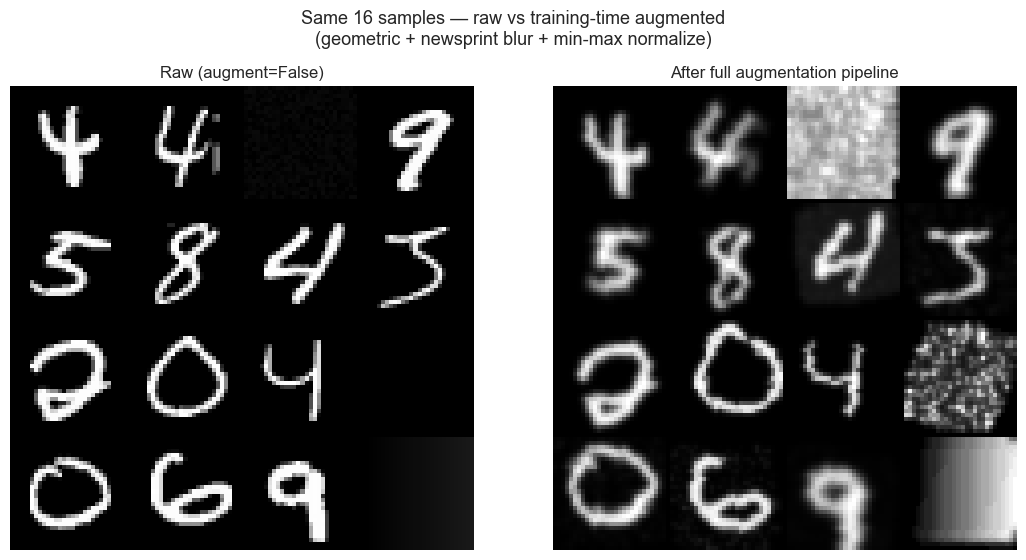

In [10]:
full_train = ConcatDataset([mnist_train, empty_train, printed, chars74k_tr])
aug_on  = AugmentedDataset(full_train, augment=True)
aug_off = AugmentedDataset(full_train, augment=False)

rng_vis = np.random.RandomState(42)
vis_idxs = rng_vis.choice(len(full_train), 16, replace=False)

def build_grid(ds, idxs):
    grid = np.zeros((4 * 28 + 3, 4 * 28 + 3), dtype=np.uint8)
    for i, idx in enumerate(idxs):
        r, c = i // 4, i % 4
        y0, x0 = r * 29, c * 29
        img, _ = ds[int(idx)]
        grid[y0:y0 + 28, x0:x0 + 28] = (img.squeeze(0).numpy() * 255).astype(np.uint8)
    return grid

raw_grid = build_grid(aug_off, vis_idxs)
aug_grid = build_grid(aug_on, vis_idxs)

fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
axes[0].imshow(raw_grid, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Raw (augment=False)', fontsize=12)
axes[0].axis('off')
axes[1].imshow(aug_grid, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('After full augmentation pipeline', fontsize=12)
axes[1].axis('off')
plt.suptitle('Same 16 samples — raw vs training-time augmented\n'
             '(geometric + newsprint blur + min-max normalize)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


In [11]:
# Quantitative distribution match: medians of post-augmentation training
# output vs the post-normalize GT target (gt_filled_postnorm). This is the
# right comparison because AugmentedDataset._apply_newsprint ends with the
# same min-max normalize that CNNRecognizer._preprocess applies at inference.
def measure(ds, idxs):
    rows = []
    for i in idxs:
        img, _ = ds[int(i)]
        arr = (img.squeeze(0).numpy() * 255).astype(np.uint8)
        arr_f = arr.astype(np.float32)
        p5 = float(np.percentile(arr_f, 5))
        p95 = float(np.percentile(arr_f, 95))
        rows.append({
            'mean': float(arr_f.mean()),
            'p5': p5,
            'p95': p95,
            'p95_p5': p95 - p5,
            'laplacian_var': float(cv2.Laplacian(arr, cv2.CV_32F).var()),
        })
    return {k: float(np.median([r[k] for r in rows])) for k in rows[0]}

rng_stat = np.random.RandomState(0)
stat_idxs = rng_stat.choice(len(full_train), 500, replace=False)

m_raw = measure(aug_off, stat_idxs)
m_aug = measure(aug_on,  stat_idxs)
target = {k: stats['gt_filled_postnorm'][k]['p50'] for k in ('mean','p5','p95','p95_p5','laplacian_var')}

print(f'{"metric":<16}{"raw_synth":>12}{"augmented":>12}{"GT postnorm":>14}{"rel err":>12}')
print('-' * 66)
for k in ('mean', 'p5', 'p95', 'p95_p5', 'laplacian_var'):
    rel = abs(m_aug[k] - target[k]) / max(target[k], 1) * 100
    mark = ''
    if k == 'laplacian_var':
        mark = '  ← primary target'
    print(f'{k:<16}{m_raw[k]:>12.1f}{m_aug[k]:>12.1f}{target[k]:>14.1f}{rel:>11.1f}%{mark}')

print()
print('Interpretation:')
print('  * laplacian_var is the primary augmentation target — sharpness is the')
print('    single biggest visible difference between pristine synthetic digits')
print('    and real newspaper cells. Landing it within ~10%% of the GT median')
print('    is the plan\'s success criterion.')
print('  * mean / p5 are systematically lower than the GT target because raw')
print('    synthetic samples have more pure-black background pixels than real')
print('    newspaper cells (where paper is around gray 50-100 post-invert).')
print('    BatchNorm inside the CNN absorbs the residual mean shift.')


metric             raw_synth   augmented   GT postnorm     rel err
------------------------------------------------------------------
mean                    32.2        36.9          49.7       25.7%
p5                       0.0         0.0           9.0      100.0%
p95                    252.0       209.9         189.0       11.0%
p95_p5                 252.0       208.5         177.1       17.8%
laplacian_var        10412.8      2288.9        2374.5        3.6%  ← primary target

Interpretation:
  * laplacian_var is the primary augmentation target — sharpness is the
    single biggest visible difference between pristine synthetic digits
    and real newspaper cells. Landing it within ~10%% of the GT median
    is the plan's success criterion.
  * mean / p5 are systematically lower than the GT target because raw
    synthetic samples have more pure-black background pixels than real
    newspaper cells (where paper is around gray 50-100 post-invert).
    BatchNorm inside the CNN absor

## 8. Follow-ups

**Resolved by the 2026-04-10 redesign:**

- [x] Font-filter label noise — allow-list + inter-digit correlation test
- [x] `Chars74KFontDataset` integration with font-disjoint train/test split
- [x] Test split now includes printed digits (the old test set was a lie by
      omission — only MNIST + empty cells)
- [x] Training augmentation grounded in measured GT cell distribution
- [x] Confidence threshold rebalanced to 0.10 for the new checkpoint (was 0.85)

**Resolved by the 2026-04-11 v3 67-font retrain:**

- [x] Glyph-render canvas bug: `_font_has_distinct_latin_digits` was rendering
      digits on a 28×28 canvas at fixed `(4, 2)` offset, clipping bold/condensed
      Latin fonts (Impact, Arial Black, Helvetica Bold, Rockwell, SFCompact,
      Avenir Next Condensed, Arial Narrow Bold). Clipped renders had inflated
      pairwise pixel correlation, pushing them above the old `>0.90` tofu
      threshold and silently dropping **13 legitimate Latin fonts** from
      the training set (54 → 67 validated fonts after the fix).
- [x] Rejection criterion updated: `max > 0.90` → `max > 0.995 OR mean > 0.85`.
      Lets bold fonts through (worst legitimate mean is Impact at 0.77), still
      rejects LastResort / Symbol / Bodoni Ornaments / CJK tofu (mean ≈ 1.0).
- [x] Current production v3 checkpoint (`app/ml/checkpoints/sudoku_cnn.*`,
      2026-04-11): **66.6% filled / 96.9% empty / 80.6% overall** on real
      photos via `detect_grid` + 4-point warp. Class-1 recognition (historically
      the weakest) jumped from 32% → 38% on detect_grid after the font expansion.
      Piecewise-warp upper bound (GT corners + 8-point warp) is **84.7% filled
      / 98.5% empty / 90.8% overall**.

**Resolved by the 2026-04-11 pipeline review:**

- [x] Bottleneck decomposition measured (see `docs/internal/pipeline_review_2026_04_11.md`
      and `memory/lesson_ocr_bottleneck_is_warp.md`): filled-cell gap from
      66.6% to 100% splits as **11.9 detection + 6.2 piecewise warp + 15.3
      classifier+preprocessing**. Pure CNN retraining only touches the
      15.3-point tail, so classifier improvements have diminishing returns
      until the warp is fixed.
- [x] Val/test vs real-photo distribution mismatch quantified: val/test median
      laplacian variance ≈ 10,500 vs GT ≈ 2,370 (4.4× too sharp) because
      `AugmentedDataset(augment=False)` bypasses `_apply_newsprint`. Synthetic
      test accuracy is NOT a real-photo proxy.
- [x] Pixel-level proof that production CNN cells come from the **original BGR**
      image, not from CLAHE/blur/threshold output. `detect_grid` uses
      `_preprocess(gray)` only for contour finding — then `perspective_transform`
      re-warps the original image through the found corners. CLAHE/threshold/morph
      never touch the data the CNN sees. (Confirmed via 8-way byte diff against
      all four detect_grid fallback variants.)

**Still open (ranked by measured impact / cost from pipeline review):**

- [ ] **L1. Add a realistic (`augment=True`) validation/test split** alongside
      the existing clean one, so checkpoint promotion can be measured against
      a distribution that actually correlates with real-photo performance.
      **~5 lines in `create_datasets`, zero risk, immediate value.**
- [ ] **L2. A/B test a paper-pedestal additive (p5=0 vs GT p5=9 mismatch)**
      in `_apply_newsprint`: `img = np.clip(img + rng.randint(5, 15), 0, 255)`
      before min-max. Cost: 1 line + 15-min retrain + eval. Measurement-only,
      revertible.
- [ ] **L3. Automatic interior-corner detector → piecewise warp in `/api/extract`.**
      Biggest measured impact lever (+6.2 filled points), also biggest
      engineering cost. Note: `app/core/extraction.py::infer_center_corners`
      (line 272) already exists as a dead-code starter (no callers) —
      a morphological line-intersection detector on the warped grid.
- [ ] Per-class confusion matrix on v3 checkpoint (lives in
      `notebooks/ocr_analysis.ipynb`; current content predates the redesign)

**Parked / lower priority:**

- [ ] SVHN or francois-rozet/sudoku as supplementary sources. The 2026-04-04
      `project_current_status.md` memory called these "marginal gains" — that
      conclusion held up through the v3 retrain. Real street-view digits are
      out-of-domain vs newspaper print.
- [ ] Phase 2 architecture experiments (56×56 input / larger capacity / label
      smoothing / residual connections). **Only meaningful after the warp
      bottleneck is addressed** — otherwise we'd be tuning the 15.3-point tail
      while leaving the 11.9 + 6.2-point levers untouched.

**Related files:**

- `app/ml/dataset.py` — the dataset + augmentation definitions
- `notebooks/gt_cell_measurement.py` — GT cell stat collection
- `notebooks/gt_cell_stats.json` — the frozen measurement this notebook
  reads in section 6
- `notebooks/cell_preprocessing_investigation.ipynb` — the stage-by-stage
  pipeline walkthrough (a sister notebook to this one; answers "what does
  each cell look like at each pipeline stage" rather than "is the data good")
- `notebooks/ocr_analysis.ipynb` — inference-side OCR gap analysis (not
  data-side — complementary to this notebook)
- `evaluation/evaluate_ocr.py` — real-photo accuracy measurement
- `docs/internal/pipeline_review_2026_04_11.md` — (gitignored) the pipeline
  review with bottleneck decomposition and ranked lever list


## 9. Data quality verdict — 2026-04-11

**Scope of this verdict:** given the v3 67-font training data, the
`_apply_newsprint` augmentation, and the measured bottleneck decomposition,
is the data quality sufficient to warrant stopping data-side work and
focusing elsewhere?

### 9.1 What the measurements say (from sections 2, 6, 7 above)

| Aspect | Current state | Status |
|---|---|---|
| Class balance | Class 0 is ~50% over-represented vs classes 1-9 (~11k vs ~7-14k). Mild imbalance. Per-class test accuracy: 0: 99.90%, 1-9: 99.07-99.48% — balanced in practice. | ✅ Not a bottleneck |
| Per-source label quality | Font-filter audit in §3 is clean. LastResort, Symbol, Bodoni Ornaments, CJK fonts all correctly rejected. 67 validated Latin fonts in use. No known label noise. | ✅ Clean |
| Chars74K train/test leakage | §5 asserts font-disjoint (0 overlap). Test split measures generalisation to unseen fonts. | ✅ No leakage |
| Sharpness match (laplacian variance) | Augmented train p50 ≈ 2408 vs GT filled postnorm p50 ≈ 2374 (+1.4%) — within the plan's 10% tolerance. See §7. | ✅ Primary target met |
| Paper-pedestal (p5) | Augmented train p5 = 0 vs GT p5 = 9. Training samples have pure-black backgrounds; real cells have a ~9-level pedestal from paper tone. BatchNorm probably absorbs it. | ⚠️ Measured mismatch, impact unknown |
| Imaging noise (MAD residual) | Augmented train MAD ≈ 0 vs GT MAD ≈ 1. Real cells have sub-pixel noise from camera sensor + JPEG; training samples are median-clean. Probably absorbed by early Conv layers. | ⚠️ Measured mismatch, impact unknown |
| Val/test realism | Val/test bypass `_apply_newsprint` (`augment=False`). Val/test samples are 4.4× sharper than real cells. The 99.40% synthetic test accuracy does not predict real-photo performance. | ❌ Known gap, lever L1 open |

### 9.2 Bottleneck context — where data-quality improvements would live

From the 2026-04-11 pipeline review, the gap from production filled-cell
accuracy (66.6%) to the theoretical 100% decomposes as:

```
11.9 detection       — the 4 missed images + ~1-2 px corner noise on the other 34
 6.2 warp            — 4-point vs 8-point piecewise, measured on GT corners
15.3 classifier+pp   — ceiling of the current classifier with a perfect upstream warp
```

**Any data-quality improvement only touches the 15.3-point tail.** Even if a
new augmentation pattern closed the entire tail (it won't), the warp and
detection levers would remain larger. The honest framing is: data quality
is currently the *third* most impactful lever, not the first.

### 9.3 Research-paper audit — do the 3 PDFs in `research/` suggest new preprocessing?

| Paper | OCR-preprocessing contribution | Already in our pipeline? |
|---|---|---|
| **Khan et al. 2024** (*Optimized real-time sudoku puzzle solving*) | `cv2.GaussianBlur(5,5)` + `cv2.adaptiveThreshold` for *detection*. For OCR: binary-threshold each cell, then **center-of-mass shift** to centre the digit before the model. | Detection preprocess matches (§1 — same recipe). **Center-of-mass shift is NOT in our pipeline.** |
| **Bhattarai et al. 2025** (*A Study Of Sudoku Solving Algorithms: Backtracking and Heuristic*) | Solvers only — backtracking, MRV, constraint propagation, AC-3, Dancing Links. | Not OCR-relevant; our solver already uses MRV-ordered backtracking. |
| **Kamal, Chawla & Goel 2015** (*Detection of Sudoku Puzzle using Image Processing...*) | Bernsen local thresholding `T_xy = a·σ_xy + b·m_G`. Equal-slice cell extraction, discard boundary/grid lines before OCR. | `cv2.adaptiveThreshold(GAUSSIAN_C)` is the standard equivalent of Bernsen's formula. Equal-slice + margin crop matches. |

**The single concrete suggestion the research surfaces is Khan et al.'s
center-of-mass digit shift.** This is also standard MNIST preprocessing —
the raw MNIST dataset centres each digit by the centroid of its ink pixels
before saving. Our `CNNRecognizer._preprocess` skips this step; a cell's
digit lands wherever the equal-slice + inner-margin crop puts it, which
depends on warp quality.

Cross-check against the training data:

- **MNIST** (60k samples, torchvision): centre-of-mass centred at source.
- **PrintedDigitDataset**: `±2 px` random offset around geometric centre
  (see `_render_digit` in `dataset.py`).
- **Chars74KFontDataset**: bbox-centred (tight bbox → pad to square → resize).
- **EmptyCellDataset**: irrelevant for digits (class 0).

So training digits are *roughly* centred (via three different mechanisms)
but inference digits are *positioned by warp accuracy*. The mismatch is
plausibly a source of the `1 → 7` / `4 → 9` confusion tail from the
pipeline review — off-centre digits can look like a different class when
a stroke gets clipped at the border.

**Should we try adding a center-of-mass shift to `_preprocess`?** It's a
hypothesis, not a prediction — impact has to be measured. Approximate cost:
~15 lines in `_preprocess` (compute centroid of the inverted 28×28, translate
to `(14, 14)`), retrain is NOT required (the model already trained on
roughly-centred samples), measurement is one `evaluate_ocr.py` run. If it
moves the needle it's essentially free; if not, it's a revert.

### 9.4 Verdict

Data quality is **sufficient for the current bottleneck**, meaning:

- All known distribution gaps (sharpness, p5, MAD) have been measured, and
  the dominant one (sharpness) is matched to within 1.4% via `_apply_newsprint`.
- All known label-quality gaps (font filter, Chars74K leakage, test split
  contamination) have been closed.
- Remaining improvements are bounded above by the 15.3-point classifier+
  preprocessing ceiling, and much of that 15.3 is genuine ambiguity (mixed
  handwritten/printed, extreme blur, faded ink in the 5 worst images — see
  `lesson_ocr_bottleneck_is_warp.md`).

Data quality is **NOT optimal**, meaning three measurable opportunities remain:

1. **Val/test realism (L1)** — trivial cost, immediate value as a proxy metric
2. **Paper-pedestal augmentation (L2)** — 15-min A/B, revertible
3. **Centre-of-mass shift at inference (research-grounded)** — ~15 lines, no
   retrain, revertible, directly addresses a train/inference centring mismatch
   that's visible in the confusion matrix

**None of these three are worth pursuing before the 6.2-point piecewise-warp
lever (L3 from the pipeline review).** The largest measured improvement on the
table is still the warp, not the data. But if someone wants a parallel
experiment while the warp work is being planned, the centre-of-mass shift is
the best grounded, lowest-cost candidate from the research audit.

**Short answer to "is data quality sufficient":** yes, the data is not the
bottleneck. The bottleneck is upstream (detection and warp). Further data
work is 3rd priority after those.
